# Kiểm chứng lựa chọn Loss Function bằng Validation (chống rò rỉ)

**Dự án Tốt nghiệp - Energy Forecasting - Nhóm The Outliers**

## 1. Mục đích

Notebook này **KHÔNG train lại gì cả** — chỉ load lại 6 model `.pkl` đã train sẵn (MAE/Huber/MSE × H1/H4) và tính WAPE trên `v5_val_selected`, tập tách biệt với train và test, để xem model nào thắng thật.

Lý do cần làm: phát hiện lỗi rò rỉ dữ liệu — bước chọn loss function trước đây đang dùng nhầm tập test thay vì validation (`metrics_val.json` bị ghi từ metric tính trên `test_h`). Notebook này verify lại bằng validation thật, không đụng test, chạy trong vài giây.

## 2. Import và cấu hình đường dẫn

In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd

BASE = '/home/tandat/Desktop/Du_An_Tot_Nghiep_v3'
VAL_PATH = f'{BASE}/data/model/v5/05_selected/v5_val_selected.parquet'
TRAIN_DIR = f'{BASE}/data/model/v5/06_train'
EPS_ELEV = 0.05
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

print('Da cau hinh duong dan. VAL_PATH =', VAL_PATH)
print('TRAIN_DIR =', TRAIN_DIR)

Da cau hinh duong dan. VAL_PATH = /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v5/05_selected/v5_val_selected.parquet
TRAIN_DIR = /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v5/06_train


## 3. Danh sách cột dịch theo horizon (`_mt`)

Sao chép đúng từ `04_1_train_mae.py` (COT_TAT_DINH) — các cột này được dịch tới thời điểm T+h thành cột mới hậu tố `_mt`, giống hệt hàm `them_muc_tieu()` trong pipeline training thật.

In [3]:
COT_TAT_DINH = [
    'solar_elevation', 'solar_azimuth', 'azimuth_sin', 'azimuth_cos', 'sin_elevation',
    'ghi_cs', 'ky_vong', 'ty_le_bao_hoa',
    'minute_of_day', 'hour_of_day', 'hour_bucket_model', 'hour', 'hour_sin', 'hour_cos',
    'minute', 'day', 'day_of_week', 'month', 'day_of_year', 'doy_sin', 'doy_cos',
]
print(f'Co {len(COT_TAT_DINH)} cot se duoc dich thanh dac trung _mt.')

Co 21 cot se duoc dich thanh dac trung _mt.


## 4. Hàm chuẩn hoá mục tiêu và tính WAPE

Giống hệt `mau_chuan_hoa()` trong script training gốc.

In [4]:
def mau_chuan_hoa(df):
    """Mau so de chuan hoa muc tieu: quy mo tram nhan sin(goc cao mat troi)."""
    return (df['site_scale'] * np.clip(df['sin_elevation_mt'], EPS_ELEV, None)).to_numpy()


def compute_wape(yt, yp):
    yt = np.asarray(yt, dtype=float)
    yp = np.asarray(yp, dtype=float)
    denom = np.sum(np.abs(yt))
    return float(np.sum(np.abs(yt - yp)) / denom * 100.0) if denom > 0 else float('nan')

print('Da dinh nghia mau_chuan_hoa va compute_wape.')

Da dinh nghia mau_chuan_hoa va compute_wape.


## 5. Nạp tập validation holdout

Đọc trực tiếp `v5_val_selected.parquet`, tự tạo `y_true` (dịch target theo horizon, giống `them_muc_tieu()`) và các cột `_mt` cần thiết. Tập này không dùng để train hoặc test.

In [5]:
# Hai tram 19 va 24 co capacity_kw khong dang tin nen da bi loai khoi train; phai loai
# ca o buoc cham diem, neu khong thi cham tren tram ma mo hinh chua he hoc.
EXCLUDE_SITES = [19, 24]

# Cac cot phan loai can dich sang moc nhan T+h de loc pham vi cho dung.
COT_NHAN = ['energy_source', 'is_daylight']


def load_val_holdout(features, horizon_steps):
    # Can doc them cac cot GOC (khong _mt) cua COT_TAT_DINH de dich thanh _mt.
    base_needed = [c[:-3] if c.endswith('_mt') and c[:-3] in COT_TAT_DINH else c for c in features]
    need = list(dict.fromkeys(
        base_needed + [SITE_COL, TIMESTAMP_COL, TARGET_COL, 'site_scale', 'sin_elevation',
                       'tran_cong_suat', 'energy_source', 'is_daylight',
                       # hai cot duoi dung de loc theo dong cho khop notebook 06/07
                       'exclude_from_training', 'has_complete_history_features']))
    d = pd.read_parquet(VAL_PATH)
    need = [c for c in need if c in d.columns]
    d = d[need].sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)

    if EXCLUDE_SITES and SITE_COL in d.columns:
        _n0 = len(d)
        d = d[~d[SITE_COL].isin(EXCLUDE_SITES)].reset_index(drop=True)
        print(f'   Loai site {EXCLUDE_SITES}: {_n0:,} -> {len(d):,} dong')

    h = int(horizon_steps)
    # SUA 2026-08-21: TRA THEO MOC THOI GIAN thay cho shift(-h) theo DONG. shift theo dong
    # chi dung khi luoi con nguyen; khi luoi thung no vo phai dong ke tiep con song va tao
    # ra mot cai nhan khong ton tai. Tra theo (site_id, timestamp) thi moc nao khong co
    # that se ra NaN va bi bo. Ap dung cho ca y_true, cot _mt va cot nhan_*.
    d['moc_nhan'] = d[TIMESTAMP_COL] + pd.Timedelta(minutes=15 * h)
    _mt_can = [c for c in COT_TAT_DINH if c in d.columns and f'{c}_mt' in features]
    _nhan_can = [c for c in COT_NHAN if c in d.columns]
    _doi = {TIMESTAMP_COL: 'moc_nhan', TARGET_COL: 'y_true'}
    _doi.update({c: f'{c}_mt' for c in _mt_can})
    _doi.update({c: f'nhan_{c}' for c in _nhan_can})
    _tra = d[[SITE_COL, TIMESTAMP_COL, TARGET_COL] + _mt_can + _nhan_can].rename(columns=_doi)
    d = d.merge(_tra, on=[SITE_COL, 'moc_nhan'], how='left')

    d = d.dropna(subset=['y_true'])
    # SUA 2026-08-21: loc theo DONG cho khop y het notebook 06 va 07. Truoc day nhanh nay
    # chi loc site_scale/sin_elevation, nen tap cham diem rong hon tap huan luyen - dong
    # thieu lich su lag (has_complete_history_features = False) va dong trong gap >= 24h
    # (exclude_from_training = True) van lot vao. Cham quan quan tren tap khac tap hoc thi
    # con so khong so sanh duoc. Loc dat SAU khi dung nhan, dung thu tu.
    if 'exclude_from_training' in d.columns:
        d = d[d['exclude_from_training'] == False]
    if 'has_complete_history_features' in d.columns:
        d = d[d['has_complete_history_features'] == True]
    return d[(d['site_scale'] > 0) & (d['sin_elevation_mt'] > EPS_ELEV)].copy()


print('Da dinh nghia load_val_holdout (v5_val_selected, loc theo nhan tai T+h).')

Da dinh nghia load_val_holdout (v5_val_selected, loc theo nhan tai T+h).


## 6. Đánh giá 1 model (load lại `.pkl`, dự báo trên validation, tính metric)

In [6]:
_VAL_CACHE = {}


def _metric_1_scope(yt, yp):
    yt = np.asarray(yt, dtype=float); yp = np.asarray(yp, dtype=float)
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2))) if len(yt) else float('nan')
    mae = float(np.mean(np.abs(yt - yp))) if len(yt) else float('nan')
    ss_res = np.sum((yt - yp) ** 2); ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    r2 = float(1 - ss_res / ss_tot) if len(yt) and ss_tot > 0 else float('nan')
    return {'wape': compute_wape(yt, yp), 'rmse': rmse, 'mae': mae, 'r2': r2, 'n': int(len(yt))}


def eval_one(loss_name, h_label):
    cfg_path = f'{TRAIN_DIR}/{loss_name}/{h_label}/model_config.json'
    pkl_path = f'{TRAIN_DIR}/{loss_name}/{h_label}/model.pkl'
    cfg = json.load(open(cfg_path))
    features = cfg['features']
    medians = cfg['feature_medians']
    horizon_steps = cfg['horizon_steps']

    # FIX (2026-08-16): truoc day o duoi cat k tai hang so 1.5 ghi cung, trong khi ba notebook
    # train (06_1/06_2/06_3) deu cat tai clip_k suy tu phan vi 99 cua k tren tap TRAIN
    # (= 1.3763921048868135). Hai nguong khac nhau -> cung mot mo hinh cho hai bo metric khac
    # nhau, ma chinh notebook nay ghi de metrics_val.json ma bao cao doc. Doc clip_k tu
    # model_config.json giong het cach 07_final_test dang lam, va bao loi neu thieu thay vi
    # am tham dung mac dinh.
    if 'clip_k' not in cfg:
        raise KeyError(
            f'{cfg_path} thieu khoa clip_k. Hay chay lai notebook train de sinh lai config.'
        )
    clip_k = float(cfg['clip_k'])

    with open(pkl_path, 'rb') as f:
        model = pickle.load(f)

    cache_key = int(horizon_steps)
    if cache_key not in _VAL_CACHE:
        _VAL_CACHE[cache_key] = load_val_holdout(features, horizon_steps)
    val = _VAL_CACHE[cache_key]

    missing_feats = [c for c in features if c not in val.columns]
    if missing_feats:
        raise KeyError(f'Thieu {len(missing_feats)} dac trung: {missing_feats[:5]}...')

    X = val[features].fillna(pd.Series(medians)).astype(np.float32)
    k_pred = np.clip(model.predict(X), 0, clip_k)
    y_pred = np.minimum(k_pred * mau_chuan_hoa(val), val['tran_cong_suat'].to_numpy() * 1.02)
    y_pred = np.where(val['sin_elevation_mt'].to_numpy() <= EPS_ELEV, 0.0, y_pred)
    y_true = val['y_true'].to_numpy()

    scope_all = _metric_1_scope(y_true, y_pred)

    # Loc theo cot NHAN tai T+h (tien to nhan_), lui ve cot tai T neu khung khong co.
    def _cot_loc(ten):
        return val[f'nhan_{ten}'] if f'nhan_{ten}' in val.columns else val.get(ten)

    mask = np.ones(len(val), dtype=bool)
    _nguon = _cot_loc('energy_source')
    if _nguon is not None:
        mask &= (_nguon == 'measured').to_numpy()
    _ngay = _cot_loc('is_daylight')
    if _ngay is not None:
        mask &= _ngay.fillna(False).astype(bool).to_numpy()
    scope_md = _metric_1_scope(y_true[mask], y_pred[mask])

    # Ghi metric tren holdout v5_val_selected de notebook 07 doc dung o lan chay tiep theo.
    out_dir = f'{TRAIN_DIR}/{loss_name}/{h_label}'
    with open(f'{out_dir}/metrics_val.json', 'w', encoding='utf-8') as f:
        json.dump({'horizon_steps': int(horizon_steps), 'loss_name': loss_name,
                   'feature_set_name': '', 'measured_daylight': scope_md,
                   'all': scope_all}, f, indent=2, ensure_ascii=False, default=str)

    return {'loss': loss_name, 'horizon': h_label, 'n_rows_val_total': len(val),
            'n_measured_daylight': scope_md['n'], 'wape_val_%': round(scope_md['wape'], 4),
            'rmse_val': round(scope_md['rmse'], 4), 'mae_val': round(scope_md['mae'], 4),
            'r2_val': round(scope_md['r2'], 4)}

print('Da dinh nghia eval_one (v5_val_selected -> metrics_val.json).')

Da dinh nghia eval_one (v5_val_selected -> metrics_val.json).


**Lưu ý:** `eval_one()` ghi `metrics_val.json` sau khi chấm trên `v5_val_selected`, nên notebook 07 đọc đúng holdout validation.

## 7. Chạy đánh giá cho cả 6 model và xác định model thắng thật

In [7]:
rows = []
for loss in ['mae', 'huber', 'mse']:
    for h in ['h1', 'h4']:
        try:
            r = eval_one(loss, h)
            rows.append(r)
            print(f"{loss:6s} {h}: WAPE_val={r['wape_val_%']:>8.4f}%  RMSE_val={r['rmse_val']:>8.4f}  "
                  f"MAE_val={r['mae_val']:>8.4f}  R2_val={r['r2_val']:>7.4f}  "
                  f"(n={r['n_measured_daylight']:,} / {r['n_rows_val_total']:,})")
        except Exception as e:
            print(f'{loss:6s} {h}: LOI - {e}')

df_ket_qua = pd.DataFrame(rows)
display(df_ket_qua)

   Loai site [19, 24]: 723,114 -> 688,680 dong
mae    h1: WAPE_val= 21.8684%  RMSE_val=  3.6201  MAE_val=  1.4967  R2_val= 0.9015  (n=288,216 / 319,957)
   Loai site [19, 24]: 723,114 -> 688,680 dong
mae    h4: WAPE_val= 25.8240%  RMSE_val=  4.1088  MAE_val=  1.7674  R2_val= 0.8731  (n=288,216 / 319,959)
huber  h1: WAPE_val= 22.1592%  RMSE_val=  3.6099  MAE_val=  1.5166  R2_val= 0.9020  (n=288,216 / 319,957)
huber  h4: WAPE_val= 25.9443%  RMSE_val=  4.0965  MAE_val=  1.7756  R2_val= 0.8738  (n=288,216 / 319,959)
mse    h1: WAPE_val= 22.4822%  RMSE_val=  3.6116  MAE_val=  1.5387  R2_val= 0.9019  (n=288,216 / 319,957)
mse    h4: WAPE_val= 26.5108%  RMSE_val=  4.1439  MAE_val=  1.8144  R2_val= 0.8709  (n=288,216 / 319,959)


,loss,horizon,n_rows_val_total,n_measured_daylight,wape_val_%,rmse_val,mae_val,r2_val
0,mae,h1,319957,288216,21.8684,3.6201,1.4967,0.9015
1,mae,h4,319959,288216,25.8240,4.1088,1.7674,0.8731
2,huber,h1,319957,288216,22.1592,3.6099,1.5166,0.9020
3,huber,h4,319959,288216,25.9443,4.0965,1.7756,0.8738
4,mse,h1,319957,288216,22.4822,3.6116,1.5387,0.9019
5,mse,h4,319959,288216,26.5108,4.1439,1.8144,0.8709


In [8]:
print('=== MODEL THANG THAT TREN VALIDATION (WAPE thap nhat, khong dung tap test) ===')
nguoi_thang = {}
for h in ['h1', 'h4']:
    sub = [r for r in rows if r['horizon'] == h]
    if sub:
        best = min(sub, key=lambda r: r['wape_val_%'])
        nguoi_thang[h] = best['loss']
        print(f"{h}: {best['loss'].upper()} thang voi WAPE_val = {best['wape_val_%']:.4f}%")
print()
print('Ket qua nay dung de CHON model, khong dung de bao cao headline.')
print('So lieu headline chinh thuc van lay tu ket_qua.json / metrics_overall.json tren tap TEST')
print('cua dung model vua thang o day (chi doc 1 lan, khong dung de chon lai).')

=== MODEL THANG THAT TREN VALIDATION (WAPE thap nhat, khong dung tap test) ===
h1: MAE thang voi WAPE_val = 21.8684%
h4: MAE thang voi WAPE_val = 25.8240%

Ket qua nay dung de CHON model, khong dung de bao cao headline.
So lieu headline chinh thuc van lay tu ket_qua.json / metrics_overall.json tren tap TEST
cua dung model vua thang o day (chi doc 1 lan, khong dung de chon lai).


## 8. Xuất kết quả ra file (để trích dẫn trong report)

In [9]:
OUT_PATH = f'{BASE}/data/model/v5/07_final_test/val_model_selection_check.json'
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
with open(OUT_PATH, 'w', encoding='utf-8') as f:
    json.dump({'ket_qua_tung_model': rows, 'model_thang': nguoi_thang}, f, indent=2, ensure_ascii=False)
print(f'Da luu: {OUT_PATH}')

Da luu: /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v5/07_final_test/val_model_selection_check.json


## Phụ lục — Thí nghiệm 7: ngân sách Optuna 20 trial đã đủ chưa?

Đặt ở đây (không phải 05b) vì nó đọc **nhật ký Optuna in ra trong output của 06_1/06_2/06_3** — chỉ tồn tại sau khi ba notebook đó chạy xong. Đây là kiểm chứng hậu kiểm, không đặt ra tham số nào.

Đường hội tụ vẽ **WAPE tốt nhất tính tới trial thứ k**: nếu đường phẳng từ trước trial cuối thì ngân sách đã bão hoà, thêm trial không cải thiện.


In [10]:
from pathlib import Path
import json, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
GOC = Path("/home/tandat/Desktop/Du_An_Tot_Nghiep_v3")

In [11]:
# ── Doc nhat ky Optuna tu ba notebook huan luyen, khong chay lai gi ──────────
import re

# Lan chay 20/08 dat N_TRIALS = 0 (khong chay Optuna, xem ly do o 06_x cell 2), nen
# notebook huan luyen MOI khong con dong "[Trial k/n] pooled WAPE". Nhat ky Optuna day du
# nam o ban sao 19/08 trong .backups/. Uu tien doc ban hien tai; neu khong co trial nao
# thi tu lui ve ban sao 19/08 va NOI RO trong output la so lieu cua lan chay nao.
_TEN_NB = {"MAE": "06_1_train_mae.ipynb", "Huber": "06_2_train_huber.ipynb",
           "MSE": "06_3_train_mse.ipynb"}
_THU_MUC_NB = [GOC / "notebooks/forcasting_v5_energy",
               GOC / ".backups/20260819_notebooks_v5"]
NB_HUAN_LUYEN = {k: _THU_MUC_NB[0] / v for k, v in _TEN_NB.items()}

def doc_output(p):
    nb = json.loads(Path(p).read_text(encoding="utf-8"))
    ra = []
    for c in nb["cells"]:
        for o in c.get("outputs", []):
            ra.extend(o.get("text", []))
            ra.extend(o.get("data", {}).get("text/plain", []))
    return "".join(ra)

MAU_TRIAL = re.compile(r"\[(H4 )?Trial\s+(\d+)/(\d+)\] pooled WAPE\s+([\d.]+)%")

nhat_ky = {}
NGUON_NHAT_KY = {}
for ten, tep in _TEN_NB.items():
    for _tm in _THU_MUC_NB:
        _p = _tm / tep
        if not _p.exists():
            continue
        _ms = list(MAU_TRIAL.finditer(doc_output(_p)))
        if _ms:
            NGUON_NHAT_KY[ten] = ('lan chay hien tai' if _tm is _THU_MUC_NB[0]
                                  else 'ban sao 19/08 (.backups)')
            for m in _ms:
                tam = "H4" if m.group(1) else "H1"
                nhat_ky.setdefault((ten, tam), []).append((int(m.group(2)), float(m.group(4))))
            break
    else:
        NGUON_NHAT_KY[ten] = 'KHONG TIM THAY nhat ky Optuna'
print("Nguon nhat ky Optuna:", NGUON_NHAT_KY)

for k in sorted(nhat_ky):
    nhat_ky[k].sort()
    print(f"  {k[0]:<6} {k[1]}: {len(nhat_ky[k])} trial | "
          f"WAPE tot nhat {min(w for _, w in nhat_ky[k]):.4f}%")

Nguon nhat ky Optuna: {'MAE': 'lan chay hien tai', 'Huber': 'lan chay hien tai', 'MSE': 'lan chay hien tai'}
  Huber  H1: 20 trial | WAPE tot nhat 23.9084%
  Huber  H4: 20 trial | WAPE tot nhat 27.8754%
  MAE    H1: 20 trial | WAPE tot nhat 23.3454%
  MAE    H4: 20 trial | WAPE tot nhat 27.5122%
  MSE    H1: 20 trial | WAPE tot nhat 24.1804%
  MSE    H4: 20 trial | WAPE tot nhat 28.2977%


Da luu hinh: data/model/v5/05_selected/hinh/hoi_tu_optuna_theo_trial.png


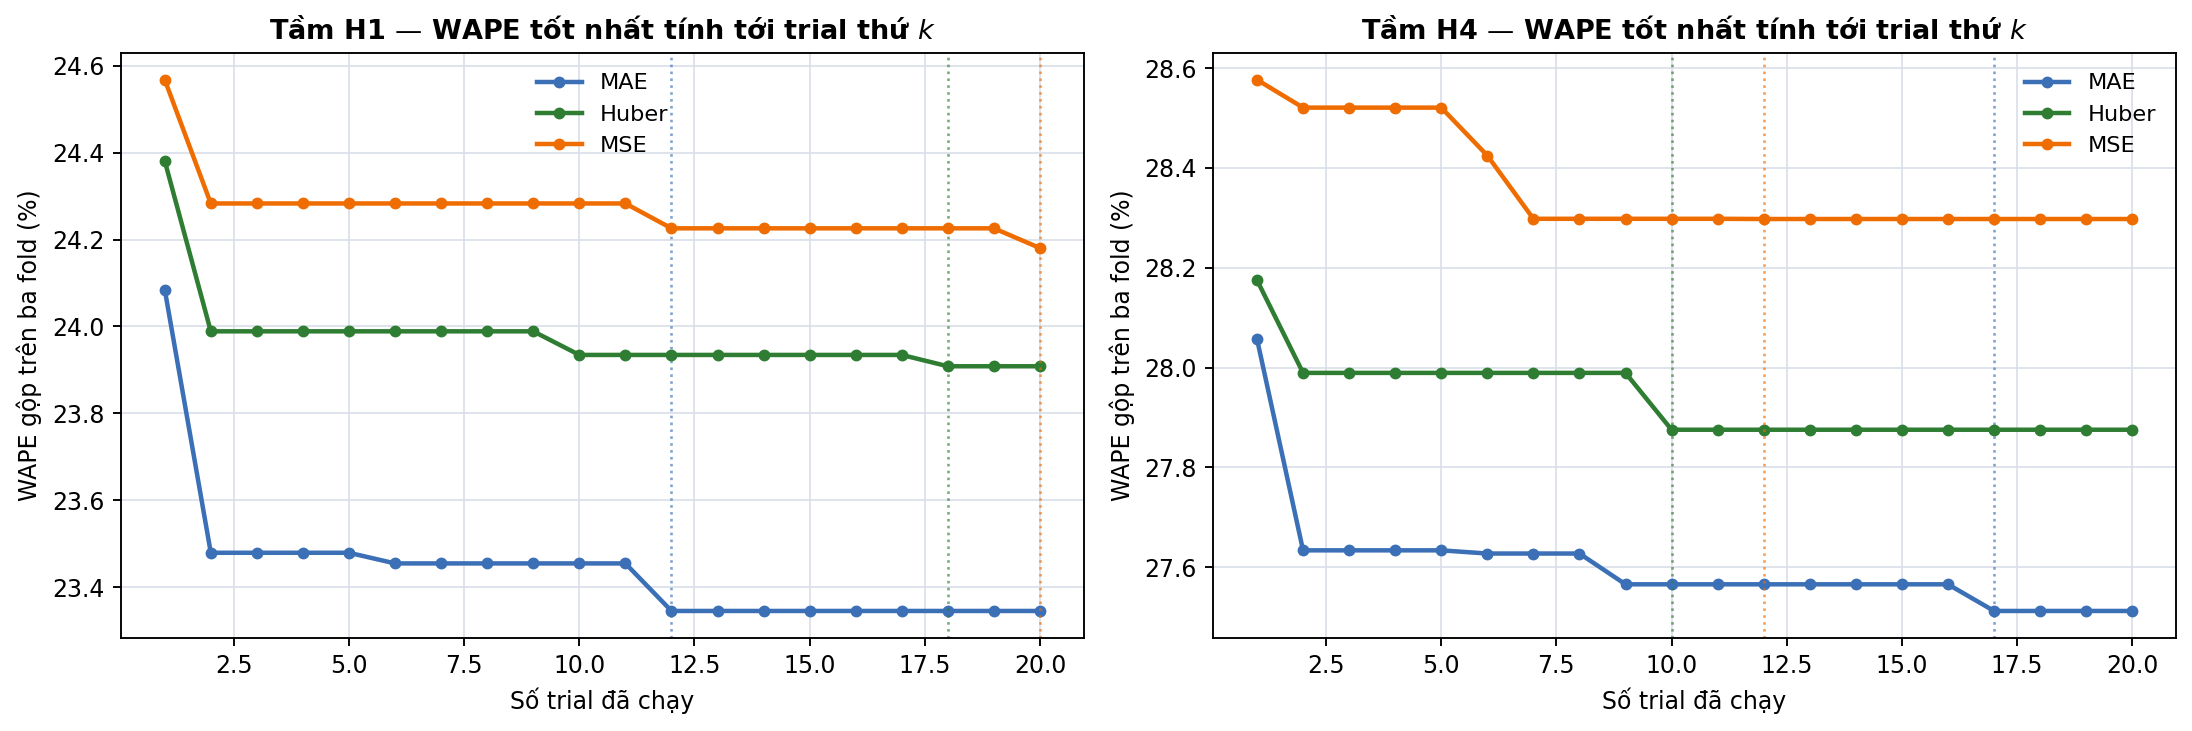

,ham_mat_mat,tam,so_trial,trial_cuoi_con_cai_thien,wape_tai_trial_20,wape_tai_trial_15,chenh_15_den_20
0,MAE,H1,20,12,23.3454,23.3454,0.0000
1,Huber,H1,20,18,23.9084,23.9345,0.0261
2,MSE,H1,20,20,24.1804,24.2258,0.0454
3,MAE,H4,20,17,27.5122,27.5656,0.0534
4,Huber,H4,20,10,27.8754,27.8754,0.0000
5,MSE,H4,20,12,28.2977,28.2977,0.0000


Da luu: data/model/v5/05_selected/hoi_tu_optuna_theo_trial.csv

Trial cuoi cung con cai thien, lon nhat trong 6 cau hinh: 20/20


In [12]:
# Tu ve: chay doc lap duoc — tu dinh nghia GOC/RA neu thieu
from pathlib import Path as _P
if 'GOC' not in dir(): GOC = _P('/home/tandat/Desktop/Du_An_Tot_Nghiep_v3')
if 'RA' not in dir(): RA = GOC / 'data/model/v5/05_selected'
(RA / 'hinh').mkdir(parents=True, exist_ok=True)

# Duong hoi tu: WAPE TOT NHAT tinh toi trial thu k
fig, truc = plt.subplots(1, 2, figsize=(13, 4.4), dpi=170)
MAU = {"MAE": "#3B6FB6", "Huber": "#2E7D32", "MSE": "#EF6C00"}

bang_bao_hoa = []
for ax, tam in zip(truc, ("H1", "H4")):
    for ten in ("MAE", "Huber", "MSE"):
        ds = nhat_ky.get((ten, tam))
        if not ds:
            continue
        x = [i for i, _ in ds]
        w = [v for _, v in ds]
        tot_dan = np.minimum.accumulate(w)
        ax.plot(x, tot_dan, "-o", color=MAU[ten], linewidth=1.9, markersize=4, label=ten)

        # Trial cuoi cung con cai thien duoc: sau moc nay ngan sach da bao hoa
        cai_thien = [i for i in range(1, len(tot_dan)) if tot_dan[i] < tot_dan[i - 1] - 1e-9]
        moc = x[cai_thien[-1]] if cai_thien else 1
        bang_bao_hoa.append({
            "ham_mat_mat": ten, "tam": tam, "so_trial": len(ds),
            "trial_cuoi_con_cai_thien": moc,
            "wape_tai_trial_20": round(float(tot_dan[-1]), 4),
            "wape_tai_trial_15": round(float(tot_dan[min(14, len(tot_dan) - 1)]), 4),
        })
        ax.axvline(moc, color=MAU[ten], ls=":", lw=1.1, alpha=0.65)

    ax.set_title(f"Tầm {tam} — WAPE tốt nhất tính tới trial thứ $k$",
                 fontsize=11.5, fontweight="bold")
    ax.set_xlabel("Số trial đã chạy")
    ax.set_ylabel("WAPE gộp trên ba fold (%)")
    ax.grid(color="#D9DEE7", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9.5)

fig.tight_layout()
_d = RA / "hinh" / "hoi_tu_optuna_theo_trial.png"
fig.savefig(_d, bbox_inches="tight", facecolor="white")
print(f"Da luu hinh: {_d.relative_to(GOC)}")
plt.show()

df_bao_hoa = pd.DataFrame(bang_bao_hoa)
df_bao_hoa["chenh_15_den_20"] = (df_bao_hoa["wape_tai_trial_15"]
                                 - df_bao_hoa["wape_tai_trial_20"]).round(4)
display(df_bao_hoa)
RA = GOC / "data/model/v5/05_selected"
df_bao_hoa.to_csv(RA / "hoi_tu_optuna_theo_trial.csv", index=False)
print(f"Da luu: {(RA / 'hoi_tu_optuna_theo_trial.csv').relative_to(GOC)}")
print(f"\nTrial cuoi cung con cai thien, lon nhat trong 6 cau hinh: "
      f"{int(df_bao_hoa['trial_cuoi_con_cai_thien'].max())}/20")